In [9]:
#Importar el modelo y describirlo superficilamente.

import torch
values = torch.load("Models/Model_Exec_710_Epoch_150_cpu_portable.pth", map_location="cpu", weights_only=False)
model = values["modelo"]
print(model)

CNN(
  (extraction): Sequential(
    (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): AvgPool2d(kernel_size=3, stride=2, padding=0)
    (4): Conv2d(64, 64, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (8): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AvgPool2d(kernel_size=3, stride=2, padding=0)
    (12): Conv2d(64, 256, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True)
    (15): AvgPool2d(kernel_s

In [10]:
#Inspeccionar la arquitectura para entender exactamente que hace internamente

import inspect

print("Tipo de modelo:", type(model))
print(inspect.getsource(model.__class__.forward))

Tipo de modelo: <class 'DeepGA.Decoding.CNN'>
  def forward(self, x):
    '''Feature extraction'''
    prev = -1
    pos = 0
    outputs = {}
    features = self.features
    #print(x.shape)
    for i in range(len(features)):
      #print(f'Layer: {i}, Input shape: {x.shape}')
      if i == 0 or i == 1:
        #print("*features[i] =  ",*features[i])
        x = nn.Sequential(*features[i])(x)
        outputs[i] = x
        #print(f'Layer: {i}, Output shape: {x.shape}')

      else:
        connections = self.second_level[pos:pos+prev]
        #print(f'Layer: {i}, Connections: {connections}')
        for c in range(len(connections)):
          if connections[c] == 1:
            skip_size = self.sizes[c][0] #Size comming from previous layer
            req_size = x.shape[2] #Current feature map size
            #print(f'Layer: {i}, Skip connection from layer {c}, Skip size: {skip_size}, Required size: {req_size}')
            if skip_size > req_size:
              psize = skip_size - re

In [14]:
#Confirmamos el vector que entra al clasificador

model.eval()

def hook_fn(module, input, output):
    print("Entrada a classifier[0]:", input[0].shape)
    print("Salida de classifier[0]:", output.shape)

hook = model.classifier[0].register_forward_hook(hook_fn)

x = torch.randn(1, 1, 128, 128)  #El tamaño de la imagen para la red es de 128px además de estar en un solo canal

with torch.no_grad():
    y = model(x)
    print("Salida final del modelo:", y.shape)

hook.remove()

Entrada al classifier[0]: torch.Size([1, 1024])
Salida de classifier[0]: torch.Size([1, 64])
Entrada a classifier[0]: torch.Size([1, 1024])
Salida de classifier[0]: torch.Size([1, 64])
Salida final del modelo: torch.Size([1, 7])


Entrada al classifier[0]: torch.Size([1, 1024])
Salida de classifier[0]: torch.Size([1, 64])
Shape del embedding: torch.Size([1, 1024])
Primeros 20 valores:
tensor([0.3107, 0.0000, 0.2805, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.2596, 0.6023, 0.4935, 1.9492, 0.6750, 0.1624,
        0.7140, 0.6383])
Longitud: 1024
Mínimo: 0.0
Máximo: 2.290231
Media: 0.29149383
Std: 0.41671157

Primeros 50 valores:
[0.31070244 0.         0.28052658 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.25962812 0.60232973 0.49348012 1.9492115  0.67498493 0.16238005
 0.71399903 0.6382813  0.8822677  0.9076869  0.6052127  0.46162996
 0.33162475 1.1363708  0.42942196 1.5859267  0.40645504 0.
 0.44663537 0.         0.         0.06548684 0.         0.14839642
 0.47665322 0.733494   0.45893365 1.3493556  0.         0.
 0.         0.         0.         0.7546122  0.2916124  0.8983368
 0.04051972 0.07301828]


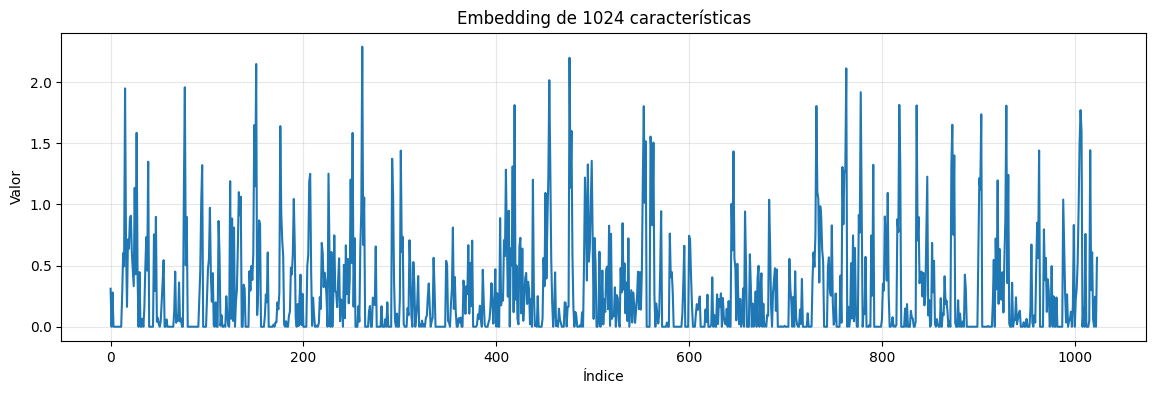

In [ ]:
#Ver salidas reales del vecto antes de entrar a la clasificación.
from PIL import Image
from torchvision import transforms

model.eval()

# Ajusta esta ruta a una imagen real de tu dataset
img_path = "Tests/2. OD 36_aug1.jpg"

# Mismo preprocesamiento real del modelo
out_size = 128
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((out_size, out_size)),
    transforms.ToTensor(),
])

img_pil = Image.open(img_path)
x = transform(img_pil).unsqueeze(0)  # [1, 1, 128, 128]

captured = {}

def hook_fn(module, input, output):
    captured["embedding_1024"] = input[0].detach().cpu()

hook = model.classifier[0].register_forward_hook(hook_fn)

with torch.no_grad():
    y = model(x)

hook.remove()

embedding = captured["embedding_1024"]

print("Shape del embedding:", embedding.shape)
print("Primeros 20 valores:")
print(embedding[0, :20])

vec = embedding[0].numpy()

print("Longitud:", len(vec))
print("Mínimo:", vec.min())
print("Máximo:", vec.max())
print("Media:", vec.mean())
print("Std:", vec.std())

print("\nPrimeros 50 valores:")
print(vec[:50])

import matplotlib.pyplot as plt

vec = embedding[0].numpy()

plt.figure(figsize=(14, 4))
plt.plot(vec)
plt.title("Embedding de 1024 características")
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.grid(True, alpha=0.3)
plt.show()

import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
plt.imshow(x[0, 0].cpu().numpy(), cmap="gray")
plt.title("Imagen preprocesada 128x128")
plt.axis("off")
plt.show()